### Setup

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit


In [178]:
def quick_plot(func,x = None,y = None,yerr = None,label = None , title = None , x_title = None , 
               y_title = None, p0 = None,log = '.'):
    """
    Uses Scipy curve_fit to automatically create comparison plot and residual plot.
    MUST define func() before using function!
    Can take inf amount of function arguments!
    Stores Scipy Perr and popt
    """

    popt, pcov = curve_fit(func,x,y,sigma = yerr, absolute_sigma = True, p0=p0)

    perr = np.sqrt(np.diag(pcov))
    
    y_fit = func(x,*popt)
    
    print(*popt)

    plt.errorbar (x, y,fmt = 'o',yerr = yerr,label = label )
    plt.plot(x,y_fit)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(title)
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.grid()
    plt.show()


    resid = y - y_fit

    plt.errorbar(x,resid,yerr = yerr, fmt = 'o',label = label)
    plt.axhline(y = 0, color = 'black', linestyle = '--')
    plt.grid()
    plt.legend()
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(title)
    plt.show()


### PRELIM EXP (DONE DONE DONE)

Standard Error of Voltage (diagnostic, not used in fit): 0.00330 V
Open Circuit Voltage = 0.0683 ± 0.0028 V
Output Resistance = 4.287 ± 0.240 Ω


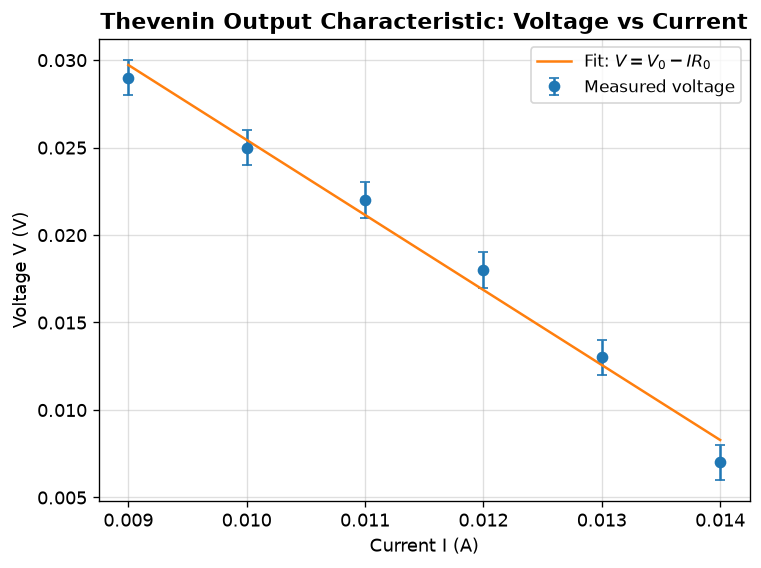

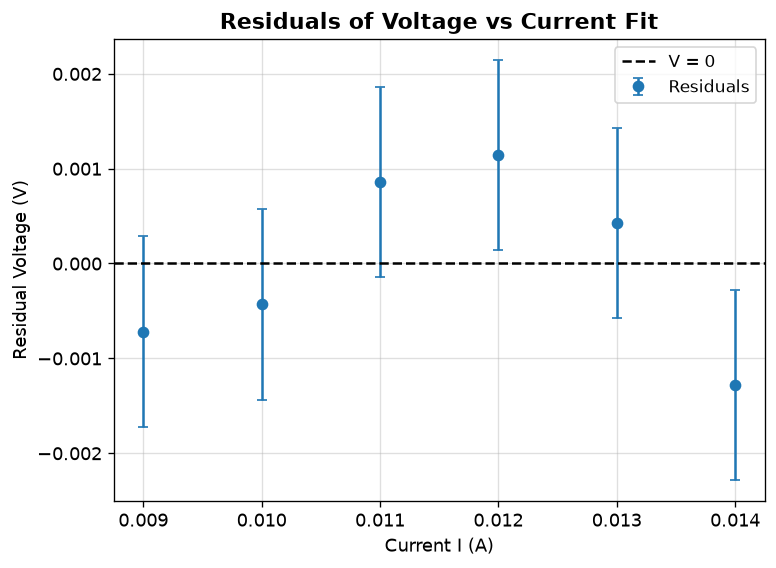

Reduced χ² = 4.55
4.548615373393412
0.3368218129799438


In [ ]:
#PRELIM EXPERIMENTE (LOAD RESISTOR)
#Uncertainty is incorrect, must go back and estimate uncertainty 
#of measurement with multimeter
I = np.array([0.014,0.013,0.012,0.011,0.010,0.009])
V = np.array([0.007,0.013,0.018,0.022,0.025,0.029])


standard_devs = np.std(V,ddof = 1)
standard_errorofV = stats.sem(V,axis=0)


accuracy = 0.4      # percent
counts = 1
resolution = 0.001  # V

sigma_v = np.sqrt(((accuracy / 100) * V)**2 + (counts * resolution)**2)


def func(I,a,R):
    return -I * R + a 

popt, pcov = curve_fit(func,I,V,sigma = sigma_v, absolute_sigma = True)

perr = np.sqrt(np.diag(pcov))

#print(perr)

a = popt[0]
R = popt[1]

print(f"Open Circuit Voltage = {a:.4f} ± {perr[0]:.4f} V")
print(f"Output Resistance = {R:.3f} ± {perr[1]:.3f} Ω")

plt.errorbar (I, V,fmt = 'o',yerr = sigma_v,capsize = 3,label = 'Measured voltage' )
plt.plot(I,a - I*R,label = r"Fit: $V=V_0-IR_0$")
plt.legend()
plt.title('Thevenin Output Characteristic: Voltage vs Current')
plt.xlabel('Current I (A)')
plt.ylabel('Voltage V (V)')
plt.grid()
plt.show()

resid = V - func(I,a,R)

plt.errorbar(I,resid,yerr = sigma_v,capsize = 3, fmt = 'o',label = "Residuals")
plt.axhline(y = 0, color = 'black', linestyle = '--',label = 'V = 0')
plt.grid()
plt.legend()
plt.xlabel("Current I (A)")
plt.ylabel('Residual Voltage (V)')
plt.title("Residuals of Voltage vs Current Fit")
plt.show()

chi2 = np.sum((resid/sigma_v)**2)
dof = len(V) - len(popt)


print(f"χ² = {chi2:.2f}")

print(chi2)

p_val = stats.chi2.sf(chi2,dof)

print(p_val)

### Resistor (DONE DONE DONE)

R = 1232.8812603310114, 13.52


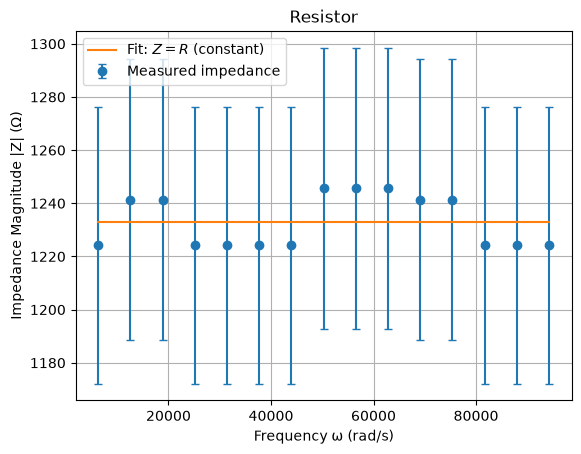

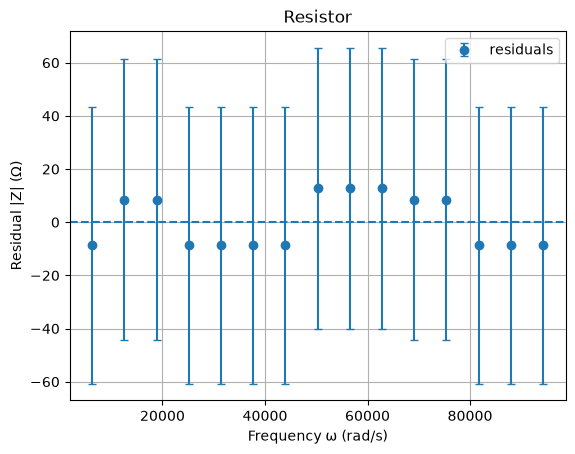

Reduced χ² = 0.50
0.9999999897693357
2.740105027584282
0.8333333333333334
Reduced χ² = 0.50
0.9999999897693357


In [ ]:
#Resistor 
import pandas as pd
import numpy as np

df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Impedance_Lab_Data/phys133_ac_circuit - Resistor.csv')
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df = df.astype(float)

f = df.iloc[::,0] *np.pi *2 


R_sense = 1000

Vr = df.iloc[:,1]
Vs = df.iloc[:,2]

z = (df.iloc[:,1]/ df.iloc[:,2]) * R_sense

rel_sigma_Vr = (0.03*Vr + 0.001)/Vr
rel_sigma_Vs = (0.03*Vs + 0.001)/Vs

sigma_z = abs(z) * np.sqrt( (rel_sigma_Vr)**2 + (rel_sigma_Vs)**2 + (0.0003)**2 )




def func(f,R):
    return  R *np.ones_like(f)

popt, pcov = curve_fit(func,f,z,sigma = sigma_z, absolute_sigma = True)

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(f,*popt)
    
print(f"R = {popt[0]}, {perr[0]:.2f}")


plt.errorbar (f, z,fmt = 'o',yerr = sigma_z,capsize = 3,label = 'Measured impedance')
plt.plot(f,y_fit,label = r"Fit: $Z=R$ (constant)")
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Impedance Magnitude |Z| (Ω)")
plt.title("Resistor")
plt.legend()
plt.grid()
plt.show()


resid = z - y_fit

plt.errorbar(f,resid,yerr = sigma_z,capsize = 3, fmt = 'o',label = 'residuals')
plt.axhline(y = 0,  linestyle = '--')
plt.grid()
plt.legend()
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Residual |Z| (Ω)")
plt.title("Resistor")
plt.show()

chi2 = np.sum((resid/sigma_z)**2)
dof = len(z) - len(popt)


print(f"χ² = {chi2:.2f}")

p_val = stats.chi2.sf(chi2,dof)

print(p_val)
 
print(((popt[0] - 1200)/1200)*100)

print((10/1200)*100)


chi2 = np.sum((resid/sigma_z)**2)


print(f"χ² = {chi2:.2f}")

p_val = stats.chi2.sf(chi2,dof)

print(p_val)







#PHASE__________________________________________________________________

### Inductor (DONE DONE)

Fitted Inductance (L): 16.9143± 0.1866


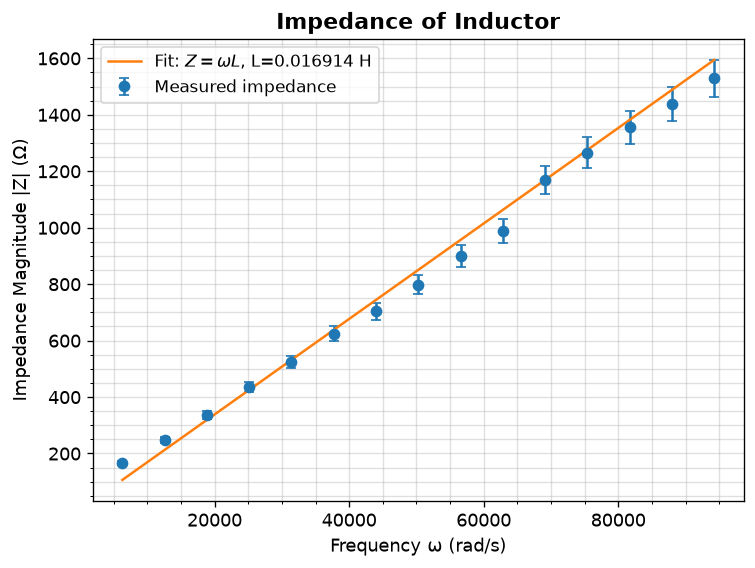

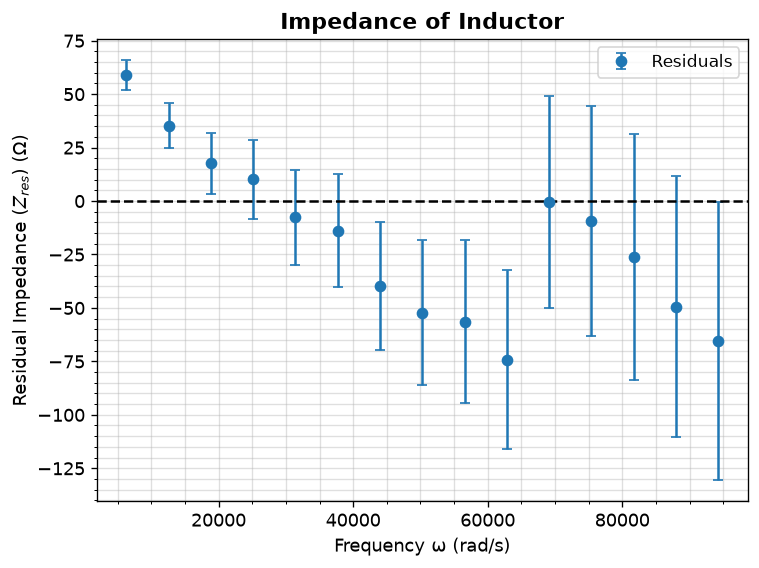

Reduced χ² = 95.12
4.0589955467150676e-14


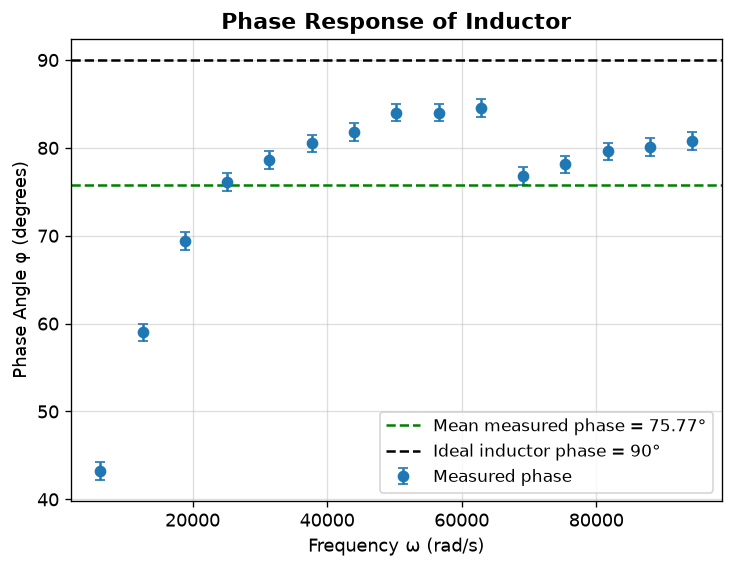

Percentage difference from known L = 15 mH: 12.76% ± 1.24%
z = 10.26σ
5.368078196539309e-25


In [ ]:
# Given data arrays
#uncertainty is incorrect, must find uncertainty of osc
#for example, we can assume a one percent error in all measurements
#due to flucuations in voltages during readings
f = (2*np.pi) * 1000 *np.linspace(1,15,15)

R_sense = 1000

df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Impedance_Lab_Data/phys133_ac_circuit - Inductor.csv')
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df = df.astype(float)

# Calculate impedance


Vr = df.iloc[:,1]
Vs = df.iloc[:,2]

z = (df.iloc[:,1]/ df.iloc[:,2]) * R_sense

rel_sigma_Vr = (0.03*Vr + 0.001)/Vr
rel_sigma_Vs = (0.03*Vs + 0.001)/Vs

sigma_z = abs(z) * np.sqrt( (rel_sigma_Vr)**2 + (rel_sigma_Vs)**2 + (0.0003)**2 )


def func(f, L):
    return f * L  

# Perform the curve fit
popt, pcov = curve_fit(func, f, z, sigma=sigma_z, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

L = popt[0]
sigma_L = perr[0]

print("Fitted Inductance (L):",f"{L*1000:.4f}" "±", f"{perr[0]*1000:.4f}")

plt.errorbar(f, z, yerr=sigma_z, capsize=3, fmt='o', label='Measured impedance')


plt.plot(f, func(f, L), '-', label=r"Fit: $Z=\omega L$" + f", L={L:.6f} H")

plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Impedance Magnitude |Z| (Ω)")
plt.minorticks_on()
plt.grid(True,which='both')
plt.title("Impedance of Inductor")
plt.legend()
plt.show()


resid = z - func(f, L)
plt.errorbar(f, resid, yerr=sigma_z, capsize=3, fmt='o', label="Residuals")
plt.axhline(y=0, color='black', linestyle='--')
plt.minorticks_on()
plt.grid(True,which='both')
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Residual Impedance ($Z_{res}$) (Ω)")
plt.title("Impedance of Inductor")
plt.legend()
plt.show()



chi2 = np.sum((resid/sigma_z)**2)
reduced_chi2 = chi2

print(f"Reduced χ² = {chi2:.2f}")

p_val = stats.chi2.sf(chi2,dof)

print(p_val)

#_______________PHASE__________________________________________________________________________

phase  = df.iloc[:,3]

sigma_phase = np.ones_like(phase) * 1 # degrees

y_fit = 90

plt.errorbar(f, phase, yerr=sigma_phase, capsize=3, fmt='o',label = 'Measured phase')
plt.axhline(y = np.mean(phase),linestyle = '--', color = 'green',label = f'Mean measured phase = {np.mean(phase):.2f}°')
plt.axhline(y = 90,linestyle = '--',color = 'black' , label = 'Ideal inductor phase = 90°')
plt.legend()
plt.grid()
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Phase Angle φ (degrees)")
plt.title("Phase Response of Inductor")
plt.show()

L_known = 15  # mH

percent_diff = ((L*1000) - L_known) / L_known * 100
sigma_percent_diff = (sigma_L*1000) / L_known * 100

print(f"Percentage difference from known L = {L_known} mH: {percent_diff:.2f}% ± {sigma_percent_diff:.2f}%")

z_score = abs((L*1000) - L_known) / (sigma_L*1000)
print(f"z = {z_score:.2f}σ")
print(stats.norm.sf(z_score))

### Capacitor (DONE DONE DONE)

<>:42: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:42: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/_c/5y50sbcs15x51qmpgmm2ftk00000gn/T/ipykernel_17661/2317914173.py:42: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  plt.xlabel(f"Inverse Frequency (1/$\omega$) (s/rad)")


Fitted Capacitor (C): 1.4870± 0.0163 nF


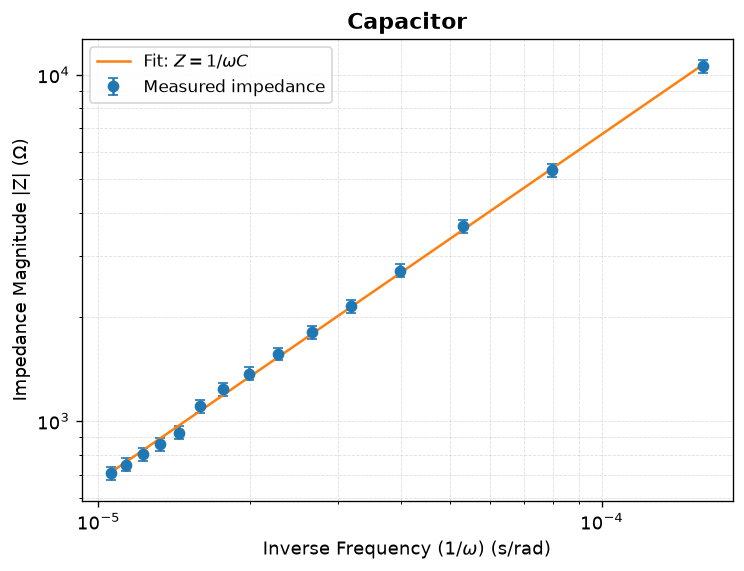

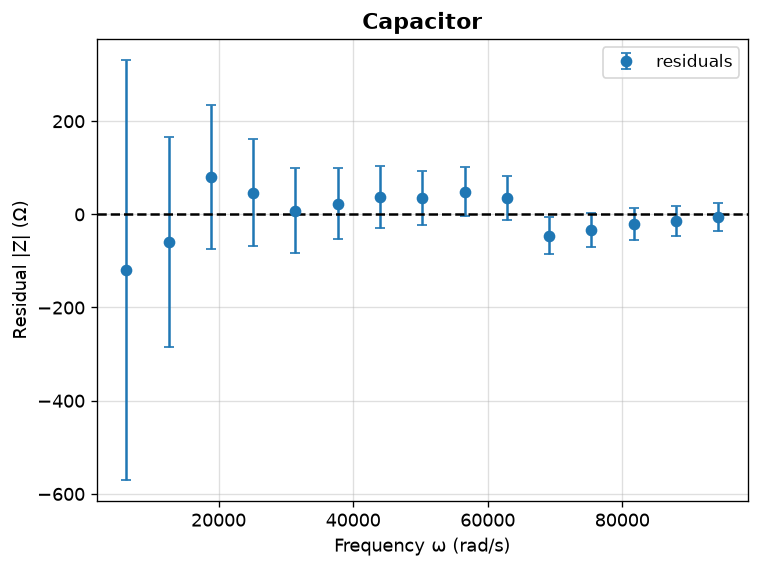

Reduced χ² = 5.58
0.9760271568767862


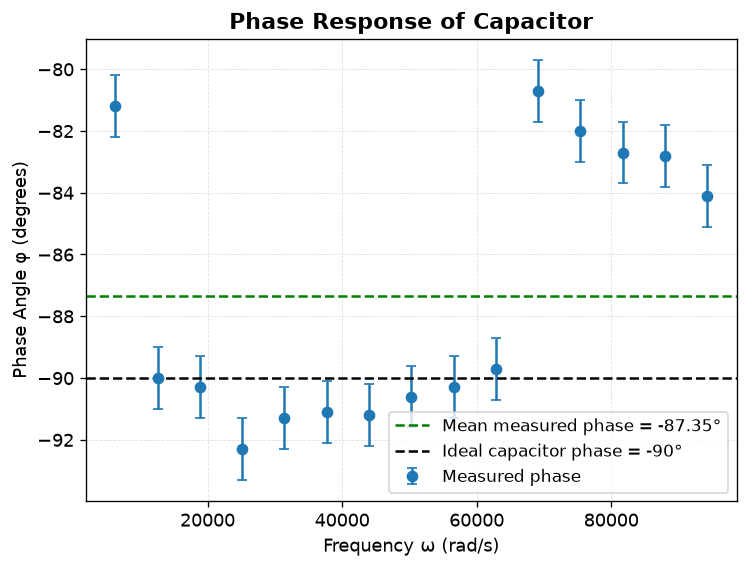

In [399]:
#Capacitor
import pandas as pd

df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Impedance_Lab_Data/phys133_ac_circuit - Capacitor.csv')
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df = df.astype(float)

R_sense = 1000

Vr = df.iloc[:,1]
Vs = df.iloc[:,2]

z = (df.iloc[:,1]/ df.iloc[:,2]) * R_sense

rel_sigma_Vr = (0.03*Vr + 0.001)/Vr
rel_sigma_Vs = (0.03*Vs + 0.001)/Vs

sigma_z = abs(z) * np.sqrt( (rel_sigma_Vr)**2 + (rel_sigma_Vs)**2 + (0.0003)**2 )


f = df.iloc[::,0] *2*np.pi

def func(f,C):
    return 1/(f*C)


popt, pcov = curve_fit(func,f,z,sigma = sigma_z, absolute_sigma = True)

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(f,*popt)

C = popt[0]

print("Fitted Capacitor (C):",f"{C*1e8:.4f}" "±", f"{perr[0]*1e8:.4f} nF")


plt.errorbar (1/f, z,fmt = 'o',yerr = sigma_z,capsize = 3,label = 'Measured impedance')
plt.plot(1/f,y_fit,label = r"Fit: $Z=1/\omega C$")
plt.legend()
plt.xlabel(f"Inverse Frequency (1/$\omega$) (s/rad)")
plt.xscale('log')
plt.yscale('log')
plt.ylabel("Impedance Magnitude |Z| (Ω)")
plt.title("Capacitor")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


resid = z - y_fit

plt.errorbar(f,resid,yerr = sigma_z,capsize = 3, fmt = 'o',label = 'residuals')
plt.axhline(y = 0, color = 'black', linestyle = '--')
plt.grid()
plt.legend()
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Residual |Z| (Ω)")
plt.title("Capacitor")
plt.show()


chi2 = np.sum((resid/sigma_z)**2)
dof = len(z) - len(popt)
reduced_chi2 = chi2

print(f"Reduced χ² = {reduced_chi2:.2f}")

p_val = stats.chi2.sf(chi2,dof)

print(p_val)


#phase_________________________________________
phase  = df.iloc[:,3]

sigma_phase = np.ones_like(phase) * 1 # degrees

y_fit = -90

plt.errorbar(f, phase, yerr=sigma_phase,capsize = 3, fmt='o',label = 'Measured phase')
plt.axhline(y = np.mean(phase),linestyle = '--', color = 'green',label = f'Mean measured phase = {np.mean(phase):.2f}°')
plt.axhline(y = -90,linestyle = '--',color = 'black' , label = 'Ideal capacitor phase = -90°')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Phase Angle φ (degrees)")
plt.title("Phase Response of Capacitor")
plt.show()

C_old = 14.78
C_sig = 0.10



### LC Parallel (DONE DONE)

0     3.116554e-06
1     1.267950e-06
2     6.516682e-07
3     3.465304e-07
4     1.871705e-07
5     1.062523e-07
6     5.529536e-08
7     2.675862e-08
8     9.620240e-09
9     2.405134e-09
10    2.693804e-09
11    9.773084e-09
12    1.864441e-08
13    3.096553e-08
14    4.559543e-08
dtype: float64
R = 7616.42 ± 1831.82 Ω
C = 12.43 ± 0.12 nF
L = 19.17 ± 0.27 mH
Resonance = 64783.37 rad/s


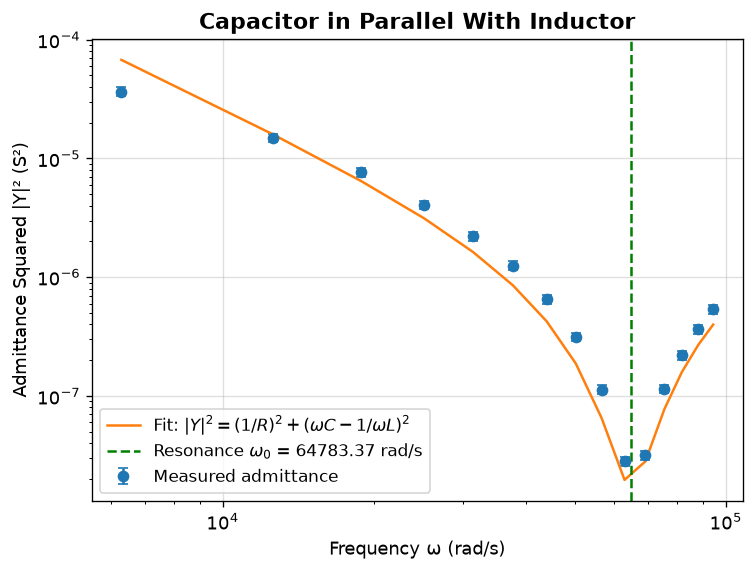

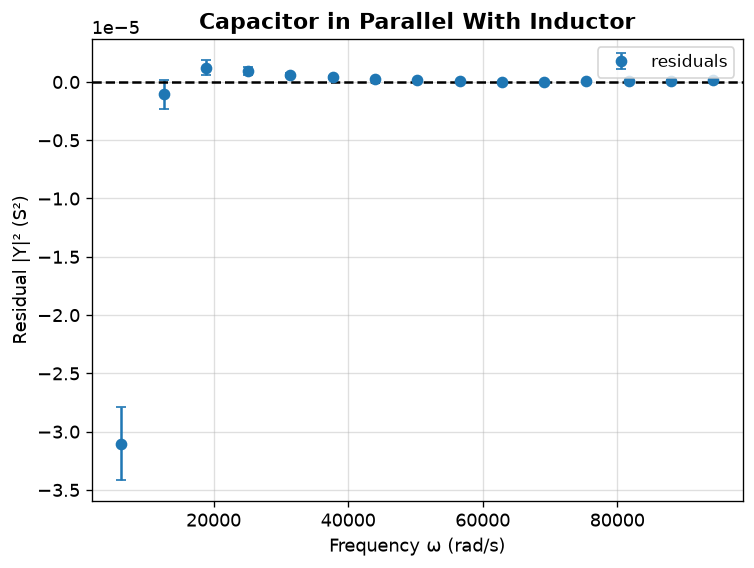

Reduced χ² (impedance) = 21.39
5.518103348491079e-48


/var/folders/_c/5y50sbcs15x51qmpgmm2ftk00000gn/T/ipykernel_17661/537580172.py:106: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_low, pcov_low = curve_fit(func_low, lowf, y_sqr, sigma=sigma_ysqr, absolute_sigma=True,


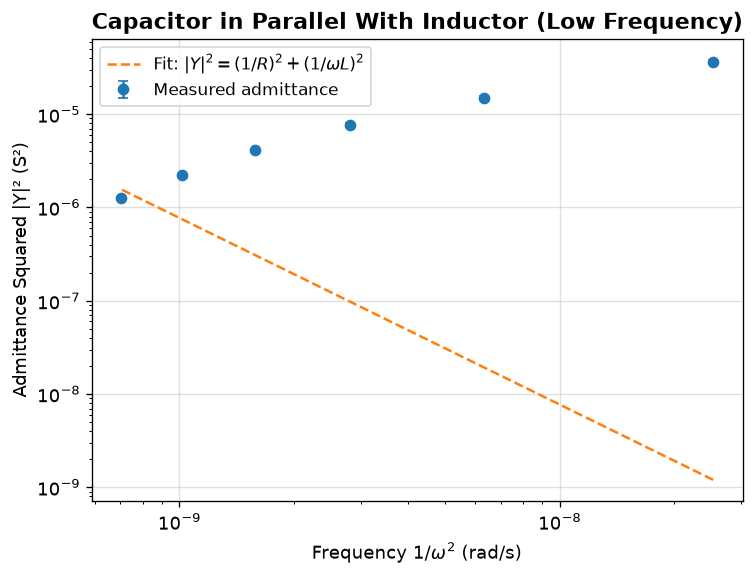

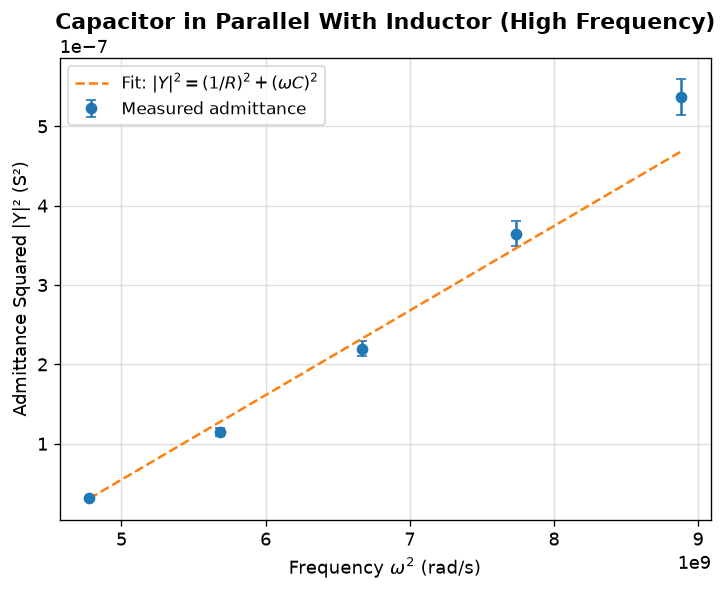

Resonance (phase) = 66946.01 rad/s


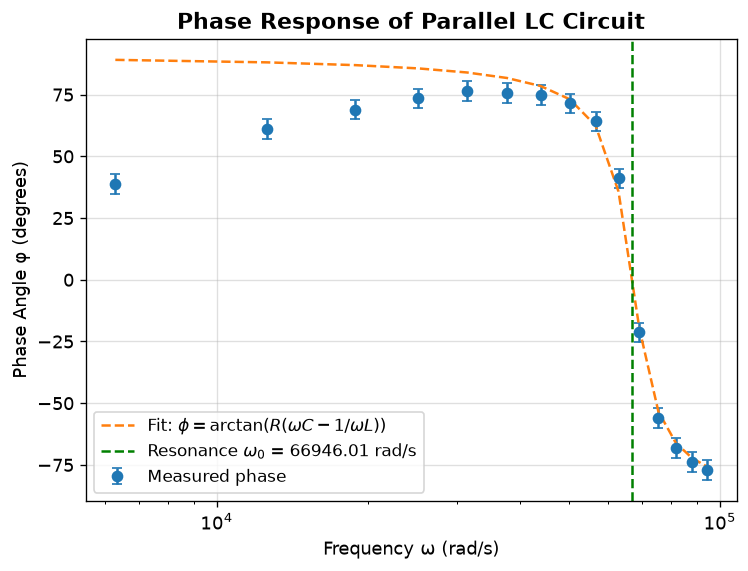

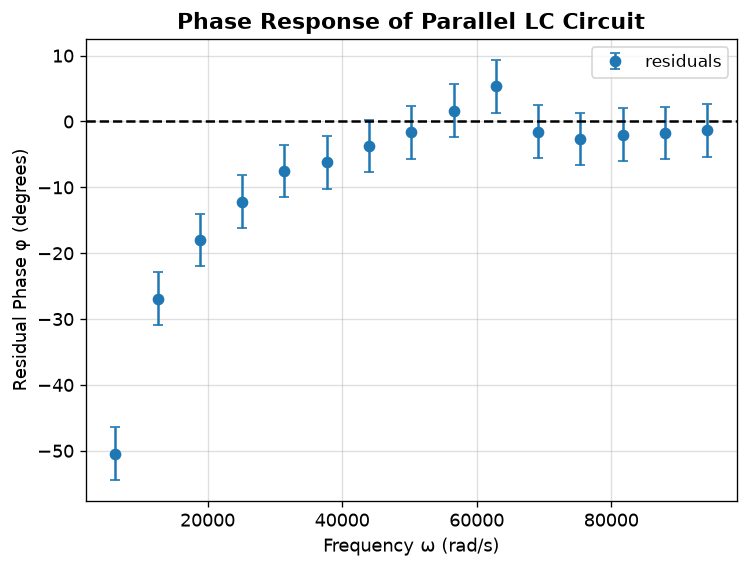

Reduced χ² (phase) = 20.33
2.4737310530348877e-45


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit






df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Impedance_Lab_Data/phys133_ac_circuit - inductor_and_capacitor_in_parallel.csv')
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df = df.astype(float)

R_sense = 1000

Vs = df.iloc[:, 1]
Vr = df.iloc[:, 2]

z = (Vs / Vr) * R_sense

y = (1 / z) ** 2

rel_sigma_Vr = (0.03 * Vr + 0.001) / Vr
rel_sigma_Vs = (0.03 * Vs + 0.001) / Vs

sigma_y = 2 * abs(y) * np.sqrt((rel_sigma_Vr) ** 2 + (rel_sigma_Vs) ** 2 + (0.0003) ** 2)

print(sigma_y)

f = df.iloc[:, 0] * 2 * np.pi

f0_guess = 6e4
C0_guess = 10e-9
L0_guess = 1 / (f0_guess**2 * C0_guess) #calculated from resonance
R0_guess = 1 / np.sqrt(min(y))

def func(f, R_int, C, L):
    return (1 / R_int) ** 2 + (f * C - 1 / (f * L)) ** 2

popt, pcov = curve_fit(func, f, y, sigma=sigma_y, absolute_sigma=True,
                        p0=[R0_guess, C0_guess, L0_guess],bounds=(0,np.inf))

perr = np.sqrt(np.diag(pcov))

y_fit = func(f, *popt)

R_int, C, L = popt

res = 1 / np.sqrt(L * C)

print(f"R = {R_int:.2f} ± {perr[0]:.2f} Ω")
print(f"C = {C*1e9:.2f} ± {perr[1]*1e9:.2f} nF")
print(f"L = {L*1e3:.2f} ± {perr[2]*1e3:.2f} mH")
print(f"Resonance = {res:.2f} rad/s")

plt.errorbar(f, y, fmt='o', yerr=sigma_y, capsize=3, label='Measured admittance')
plt.plot(f, y_fit, label=r"Fit: $|Y|^2=(1/R)^2+(\omega C - 1/\omega L)^2$")
plt.axvline(res, linestyle='--', color='green', label=fr"Resonance $\omega_0$ = {res:.2f} rad/s")
plt.legend()
plt.xlabel("Frequency ω (rad/s)")
plt.xscale('log')
plt.yscale('log')
plt.ylabel("Admittance Squared |Y|² (S²)")
plt.title("Capacitor in Parallel With Inductor")
plt.grid(True)
plt.show()

resid = y - y_fit

plt.errorbar(f, resid, yerr=sigma_y, capsize=3, fmt='o', label='residuals')
plt.axhline(y=0, color='black', linestyle='--')
plt.grid()
plt.legend()
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Residual |Y|² (S²)")
plt.title("Capacitor in Parallel With Inductor")
plt.show()

chi2 = np.sum((resid / sigma_y) ** 2)
dof = len(y) - len(popt)
reduced_chi2 = chi2 / dof

print(f"χ² (impedance) = {chi2:.2f}")


p_val = stats.chi2.sf(chi2,dof)

print(p_val)






lowf = np.array(list(1/f**2)[:6])
y_sqr = np.array(list(y)[:6])

sigma_ysqr = np.array(abs(y_sqr) * np.sqrt((rel_sigma_Vr[:6]) ** 2 + (rel_sigma_Vs[:6]) ** 2 + (0.0003) ** 2))


def func_low(lowf, R_int, L):
    return (1 / R_int ** 2) + (1 / (lowf * L)) ** 2

popt_low, pcov_low = curve_fit(func_low, lowf, y_sqr, sigma=sigma_ysqr, absolute_sigma=True,
                                p0=[R0_guess, L0_guess])

perr_low = np.sqrt(np.diag(pcov_low))

y_fit_low = func_low(lowf, *popt_low)

plt.errorbar(lowf, y_sqr, yerr=sigma_ysqr, capsize=3, fmt='o', label='Measured admittance')
plt.plot(lowf, y_fit_low, linestyle='--', label=r"Fit: $|Y|^2=(1/R)^2+(1/\omega L)^2$")
plt.grid()
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Frequency $1/ω^2 $ (rad/s)")
plt.ylabel("Admittance Squared |Y|² (S²)")
plt.title("Capacitor in Parallel With Inductor (Low Frequency)")
plt.show()









highf = np.array(list(f**2)[10:])
y_sqr_high = np.array(list(y)[10:])

sigma_ysqr_high = np.array(abs(y_sqr_high) * np.sqrt((rel_sigma_Vr[10:]) ** 2 + (rel_sigma_Vs[10:]) ** 2 + (0.0003) ** 2))

def func_high(highf, m, C):
    return m*(highf) + C

popt_high, pcov_high = curve_fit(func_high, highf, y_sqr_high, sigma=sigma_ysqr_high, absolute_sigma=True,
                                  p0=[1/R0_guess, C0_guess])

perr_high = np.sqrt(np.diag(pcov_high))

y_fit_high = func_high(highf, *popt_high)

plt.errorbar(highf, y_sqr_high, yerr=sigma_ysqr_high, capsize=3, fmt='o', label='Measured admittance')
plt.plot(highf, y_fit_high, linestyle='--', label=r"Fit: $|Y|^2=(1/R)^2+(\omega C)^2$")

plt.grid()
plt.legend()
plt.xlabel("Frequency $ω^2$ (rad/s)")
plt.ylabel("Admittance Squared |Y|² (S²)")
plt.title("Capacitor in Parallel With Inductor (High Frequency)")
plt.show()




#Phase___________________________________________________________
phase  = df.iloc[:,3]

sigma_phase = np.ones_like(phase) * 4 # degrees

C = None
L = None

def func(f,R_int,C,L):
    return np.degrees(np.arctan(R_int*(f*C - (1/(f*L)))))


popt, pcov = curve_fit(func,f,phase,sigma = sigma_phase, absolute_sigma = True,p0=[1000,1e-8,1e-3])

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(f,*popt)

R_int_phase, C_phase, L_phase = popt

res_phase = 1 / np.sqrt(L_phase * C_phase)

print(f"Resonance (phase) = {res_phase:.2f} rad/s")


plt.errorbar(f, phase, yerr=sigma_phase, capsize=3, fmt='o',label = 'Measured phase')
plt.plot(f,y_fit,label = r"Fit: $\phi=\arctan(R(\omega C - 1/\omega L))$",linestyle = '--')
plt.axvline(res_phase, linestyle='--', color='green', label=fr"Resonance $\omega_0$ = {res_phase:.2f} rad/s")
plt.legend()
plt.grid()
plt.xscale('log')
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Phase Angle φ (degrees)")
plt.title("Phase Response of Parallel LC Circuit")
plt.show()


resid = phase - y_fit

plt.errorbar(f,resid,yerr = sigma_phase, capsize=3, fmt = 'o',label = 'residuals')
plt.axhline(y = 0, color = 'black', linestyle = '--')
plt.grid()
plt.legend()
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Residual Phase φ (degrees)")
plt.title("Phase Response of Parallel LC Circuit")
plt.show()

chi2 = np.sum((resid/sigma_phase)**2)
dof = len(phase) - len(popt)


print(f" χ² (phase) = {chi2:.2f}")


p_val = stats.chi2.sf(chi2,dof)

print(p_val)

### LC Series (DONE DONE)

R = 170.37 ± 6.71 Ω
C = -14.30 ± 0.19 nF
L = -16.19 ± 0.22 mH
Resonance = 65722.40 rad/s


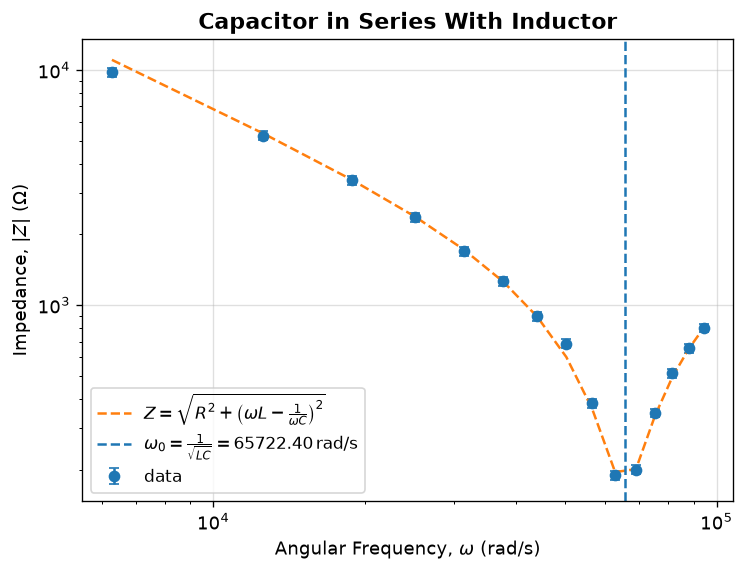

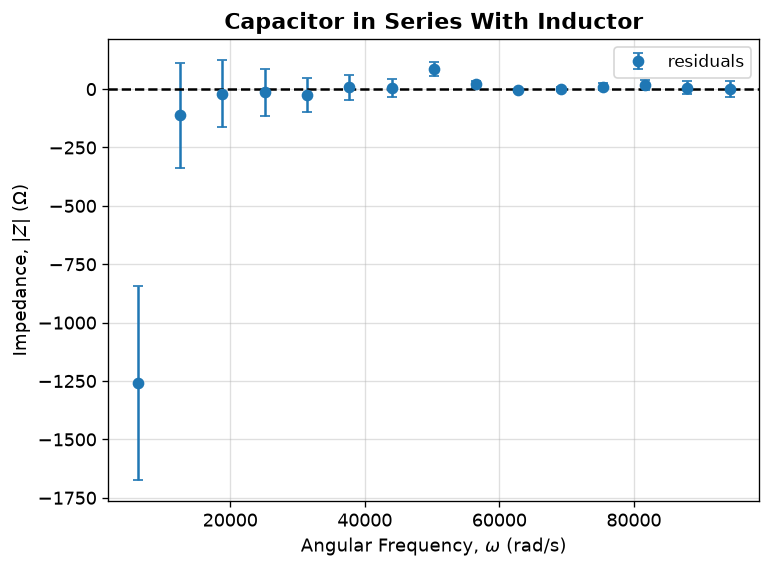

Reduced χ² (impedance) = 1.77
0.04681282555585747


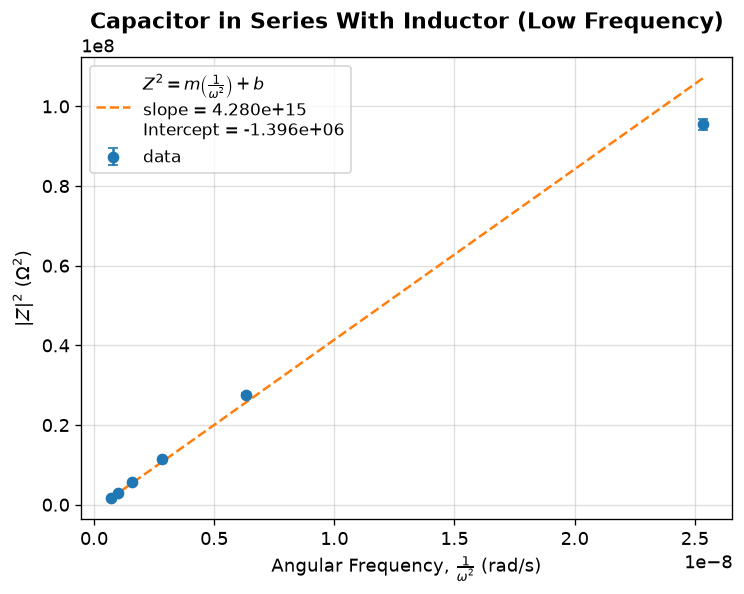

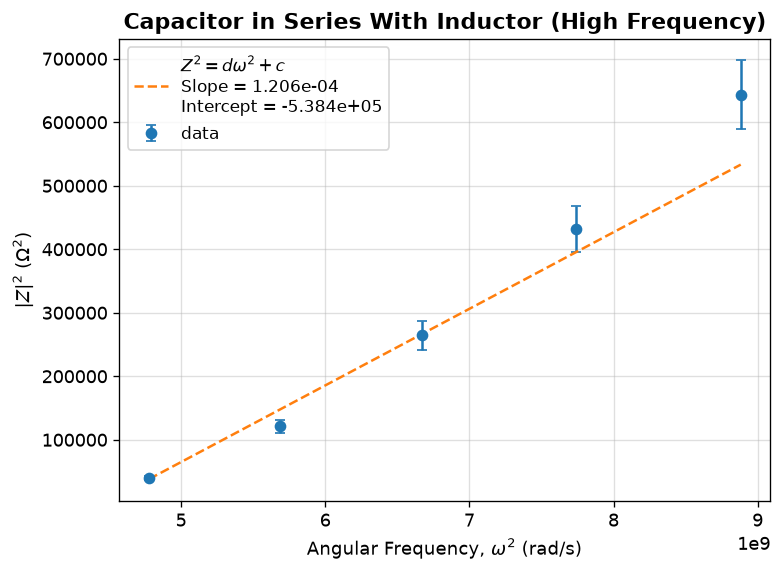

Resonance at 67642.31 rad/s


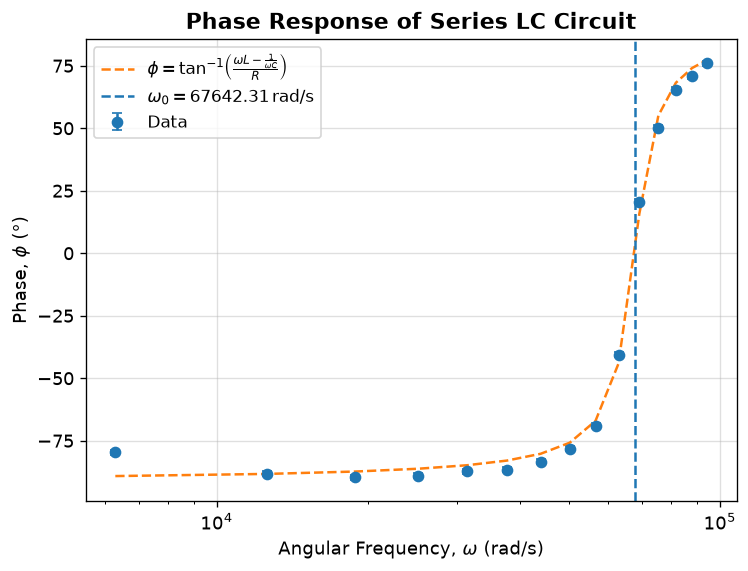

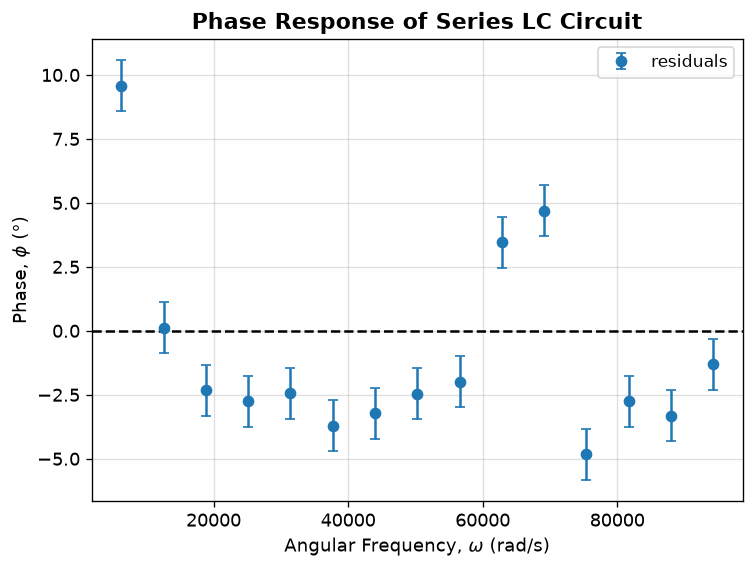

Reduced χ² (impedance) = 18.56
6.54255282980758e-41
212381.72967060987


In [ ]:
#Inductor and Capacitor In Series

import pandas as pd

df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Impedance_Lab_Data/phys133_ac_circuit - inductor_and_capacitor_in_series.csv')
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df = df.astype(float)

phase = df.iloc[:,3]

f = df.iloc[::,0] *np.pi *2 

R_sense = 1000

Vr = df.iloc[:,1]
Vs = df.iloc[:,2]

z = (df.iloc[:,1]/ df.iloc[:,2]) * R_sense

rel_sigma_Vr = (0.03*Vr + 0.001)/Vr
rel_sigma_Vs = (0.03*Vs + 0.001)/Vs

sigma_z = abs(z) * np.sqrt( (rel_sigma_Vr)**2 + (rel_sigma_Vs)**2 + (0.0003)**2 )


def func(f,L,C,R):
    return np.sqrt(R**2 + (f*L - 1/(f*C))**2)

popt, pcov = curve_fit(func,f,z,sigma = sigma_z, absolute_sigma = True,p0=[2000, 1e-7, 0.1])

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(f,*popt)


L = popt[0]
C = popt[1]
R_int = popt[2]
res = 1/np.sqrt(L*C)

print(f"R = {R_int:.2f} ± {perr[2]:.2f} Ω")
print(f"C = {C*1e9:.2f} ± {perr[1]*1e9:.2f} nF")
print(f"L = {L*1e3:.2f} ± {perr[0]*1e3:.2f} mH")
print(f"Resonance = {res:.2f} rad/s")

plt.errorbar (f, z,fmt = 'o',yerr = sigma_z,label = 'data',capsize=3)
plt.plot(
    f,
    y_fit,
    '--',
    label=(
        r"$Z=\sqrt{R^2+\left(\omega L-\frac{1}{\omega C}\right)^2}$"
    )
)
plt.axvline(res,linestyle = '--', label = rf"$\omega_0=\frac{{1}}{{\sqrt{{LC}}}}={res:.2f}\,\mathrm{{rad/s}}$")
plt.legend()
plt.xlabel(r"Angular Frequency, $\omega$ (rad/s)")
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r"Impedance, $|Z|$ ($\Omega$)")
plt.title("Capacitor in Series With Inductor")
plt.grid()
plt.show()


resid = z - y_fit

plt.errorbar(f,resid,yerr = sigma_z, fmt = 'o',label = 'residuals',capsize=3)
plt.axhline(y = 0, color = 'black', linestyle = '--')
plt.grid()
plt.legend()
plt.xlabel(r"Angular Frequency, $\omega$ (rad/s)")
plt.ylabel(r"Impedance, $|Z|$ ($\Omega$)")
plt.title("Capacitor in Series With Inductor")
plt.show()

chi2 = np.sum((resid/sigma_z)**2)
dof = len(z) - len(popt)
reduced_chi2 = chi2/dof

print(f"χ² (impedance) = {chi2:.2f}")

p_val = stats.chi2.sf(chi2,dof)

print(p_val)


#Low Frequency

C = None

lowf = list(1/f**2)[:6]
z_sqr = list(z**2)[:6]

lowf = np.array(lowf)
z_sqr = np.array(z_sqr)

sigma_zsqr = z_sqr * np.sqrt( (0.01)**2 + (0.01)**2 + (0.0003)**2 )

sigma_zsqr = np.array(list(sigma_zsqr)[:6])

def func(lowf,m,b):
    return (m*lowf) + b

popt, pcov = curve_fit(func,lowf,z_sqr,sigma = sigma_zsqr, absolute_sigma = True,p0 =[1e14,100])

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(lowf,*popt)

plt.errorbar(lowf,z_sqr,yerr = sigma_zsqr,fmt = 'o',label  = 'data',capsize = 3)
plt.plot(lowf,y_fit,linestyle = '--',label=(
    r"$Z^2=m\left(\frac{1}{\omega^2}\right)+b$"
    f"\nslope = {popt[0]:.3e}"
    f"\nIntercept = {popt[1]:.3e}"
))
plt.grid()
plt.legend()
plt.xlabel(r"Angular Frequency, $\frac{1}{\omega ^2}$ (rad/s)")
plt.ylabel(r"$|Z|^2$ ($\Omega^2$)")
plt.title("Capacitor in Series With Inductor (Low Frequency)")
plt.show()


#High Frequency

C = None
lowf = None 
z_sqr = None 
sigma_zsqr = None

highf = list(f**2)[10:15]
z_sqr = list(z**2)[10:15]

highf = np.array(highf)
z_sqr = np.array(z_sqr)

sigma_zsqr = 2*z[10:15]*sigma_z[10:15]

sigma_zsqr = np.array(list(sigma_zsqr))

def func(highf,d,c):
    return d*highf + c

popt, pcov = curve_fit(func,highf,z_sqr,sigma = sigma_zsqr, absolute_sigma = True,p0 =[1e14,100])

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(highf,*popt)

plt.errorbar(highf,z_sqr,yerr = sigma_zsqr,fmt = 'o',label = 'data',capsize = 3)
plt.plot(highf,y_fit,linestyle = '--',label=(
    r"$Z^2=d\omega^2+c$"
    f"\nSlope = {popt[0]:.3e}"
    f"\nIntercept = {popt[1]:.3e}"
))
plt.grid()
plt.legend()
plt.xlabel(r"Angular Frequency, $\omega ^2$ (rad/s)")
plt.ylabel(r"$|Z|^2$ ($\Omega^2$)")
plt.title("Capacitor in Series With Inductor (High Frequency)")
plt.show()






#_______________PHASE__________________________________________________________________________



sigma_phase = np.ones_like(phase) * 1 # degrees

def func(f,L,C,R_int):
    return np.degrees(np.arctan(((f*L)-(1/(f*C)))/R_int))


popt, pcov = curve_fit(func,f,phase,sigma = sigma_phase, absolute_sigma = True, p0=[0.01,1e-7,10],
    bounds=(0,np.inf),
    maxfev=10000
)

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(f,*popt)

L = popt[0]
C = popt[1]
res = 1/np.sqrt(L*C)

print(f"Resonance at {res:.2f} rad/s")

plt.errorbar(f, phase, yerr=sigma_phase, fmt='o',label = 'Data',capsize = 3)
plt.plot(f,y_fit,label=(
    r"$\phi=\tan^{-1}\!\left(\frac{\omega L-\frac{1}{\omega C}}{R}\right)$"
),linestyle = '--')
plt.axvline(res,linestyle = '--',label = rf"$\omega_0={res:.2f}\,\mathrm{{rad/s}}$")
plt.legend()
plt.grid()
plt.xlabel(r"Angular Frequency, $\omega$ (rad/s)")
plt.ylabel(r"Phase, $\phi$ (°)")
plt.title("Phase Response of Series LC Circuit")
plt.xscale('log')
plt.show()


resid = phase - y_fit

plt.errorbar(f,resid,yerr = sigma_phase, fmt = 'o',label = 'residuals',capsize = 3)
plt.axhline(y = 0, color = 'black', linestyle = '--')
plt.grid()
plt.legend()
plt.xlabel(r"Angular Frequency, $\omega$ (rad/s)")
plt.ylabel(r"Phase, $\phi$ (°)")
plt.title("Phase Response of Series LC Circuit")
plt.show()

chi2 = np.sum((resid/sigma_phase)**2)
dof = len(phase) - len(popt)


print(f"χ² (impedance) = {chi2:.2f}")
p_val = stats.chi2.sf(chi2,dof)

print(p_val)


L = 0.0015
C = 14.78*1e-9

res_rel = 1/(np.sqrt(L*C))
print(res_rel)


### RL Series (DONE DONE)

R = 1346.62 ± 26.35 Ω
L = 16.37 ± 0.72 mH


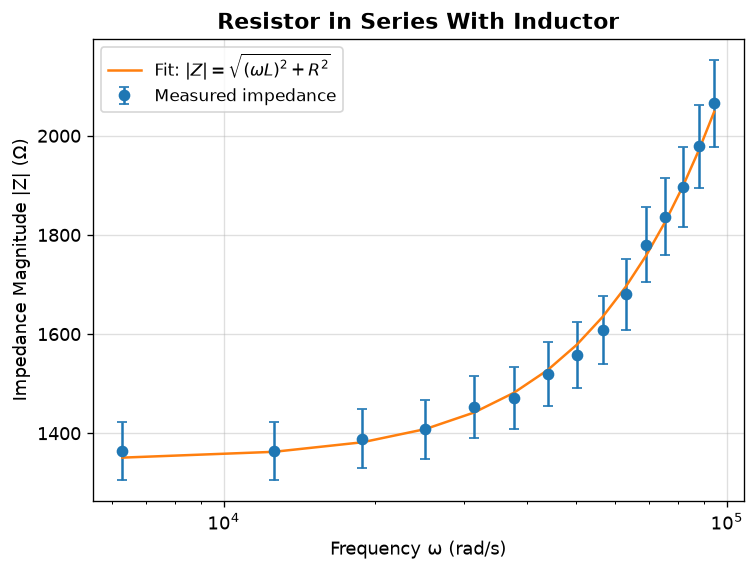

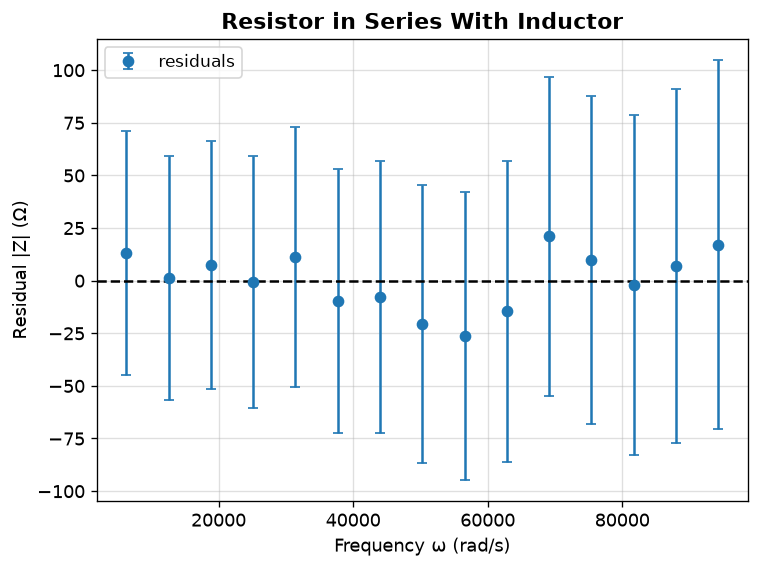

Reduced χ² = 0.57
p-value = 1.00
Inductance: 119.95mH
Total Resistance: 10560.09oh


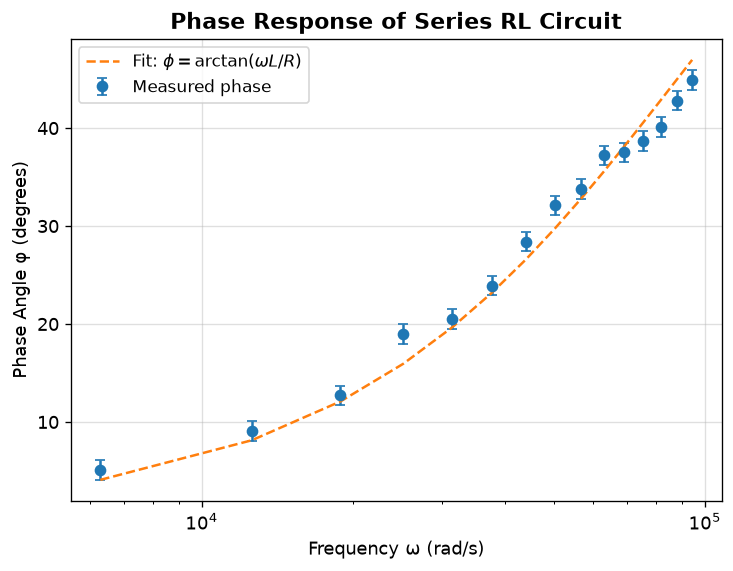

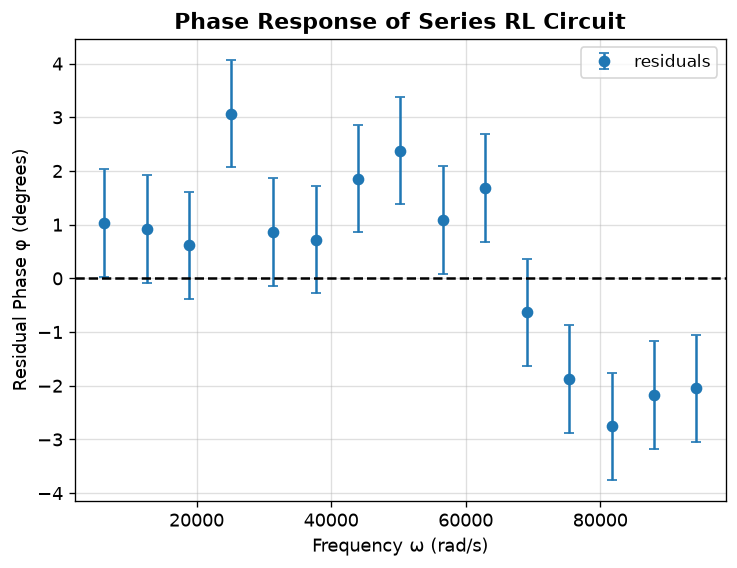

Reduced χ² (phase) = 46.50
p-value = 0.00


In [ ]:
#Inductor and Resistor In Series 

import pandas as pd
import numpy as np

df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Impedance_Lab_Data/phys133_ac_circuit - inductor_and_resistor_in_series.csv')
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df = df.astype(float)

f = df.iloc[::,0] *np.pi *2 

R_sense = 1000
Vr = df.iloc[:,1]
Vs = df.iloc[:,2]

z = (df.iloc[:,1]/ df.iloc[:,2]) * R_sense

rel_sigma_Vr = (0.03*Vr + 0.001)/Vr
rel_sigma_Vs = (0.03*Vs + 0.001)/Vs

sigma_z = abs(z) * np.sqrt( (rel_sigma_Vr)**2 + (rel_sigma_Vs)**2 + (0.0003)**2 )


def func(f,L,R_tot):
    return np.sqrt(((f*L)**2) + (R_tot)**2)

popt, pcov = curve_fit(func,f,z,sigma = sigma_z, absolute_sigma = True,p0 = [15*1e-3,1000])

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(f,*popt)
    
L = popt[0]
R = popt[1]

print(f"R = {R:.2f} ± {perr[1]:.2f} Ω")
print(f"L = {L*1e3:.2f} ± {perr[0]*1e3:.2f} mH")

plt.errorbar (f, z,fmt = 'o',yerr = sigma_z,capsize = 3,label = 'Measured impedance')
plt.plot(f,y_fit,label = r"Fit: $|Z|=\sqrt{(\omega L)^2+R^2}$")
plt.legend()
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Impedance Magnitude |Z| (Ω)")
plt.xscale('log')
plt.title("Resistor in Series With Inductor")
plt.grid()
plt.show()


resid = z - y_fit

plt.errorbar(f,resid,yerr = sigma_z,capsize = 3, fmt = 'o',label = 'residuals')
plt.axhline(y = 0, color = 'black', linestyle = '--')
plt.grid()
plt.legend()
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Residual |Z| (Ω)")
plt.title("Resistor in Series With Inductor")
plt.show()

chi2 = np.sum((resid/sigma_z)**2)
dof = len(z) - len(popt)


print(f"χ² = {reduced_chi2:.2f}")
p_val = stats.chi2.sf(chi2,dof)

print(f"p-value = {p_val:.2f}")









#_______________PHASE__________________________________________________________________________

phase  = df.iloc[:,3]

sigma_phase = np.ones_like(phase) * 1 # degrees

L = None
R = None

def func(f,L,R):
    return np.degrees(np.arctan((f*L)/R))


popt, pcov = curve_fit(func,f,phase,sigma = sigma_phase, absolute_sigma = True,p0=[0.1, 10])

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(f,*popt)

L = popt[0]
R = popt[1]

print(f"Inductance: {L*1000:.2f}mH")
print(f"Total Resistance: {R:.2f}oh")


plt.errorbar(f, phase, yerr=sigma_phase,capsize = 3, fmt='o',label = 'Measured phase')
plt.plot(f,y_fit,label = r"Fit: $\phi=\arctan(\omega L/R)$",linestyle = '--')
plt.legend()
plt.grid()
plt.xscale('log')
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Phase Angle φ (degrees)")
plt.title("Phase Response of Series RL Circuit")
plt.show()


resid = phase - y_fit

plt.errorbar(f,resid,yerr = sigma_phase,capsize = 3, fmt = 'o',label = 'residuals')
plt.axhline(y = 0, color = 'black', linestyle = '--')
plt.grid()
plt.legend()
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Residual Phase φ (degrees)")
plt.title("Phase Response of Series RL Circuit")
plt.show()

chi2 = np.sum((resid/sigma_phase)**2)
dof = len(phase) - len(popt)
reduced_chi2 = chi2

print(f"χ² (phase) = {reduced_chi2:.2f}")
p_val = stats.chi2.sf(chi2,dof)

print(f"p-value = {p_val:.2f}")

### RC SERIES (DONE DONE)

R = 1195.38 ± 35.04 Ω
C = -14.55 ± 0.31 nF


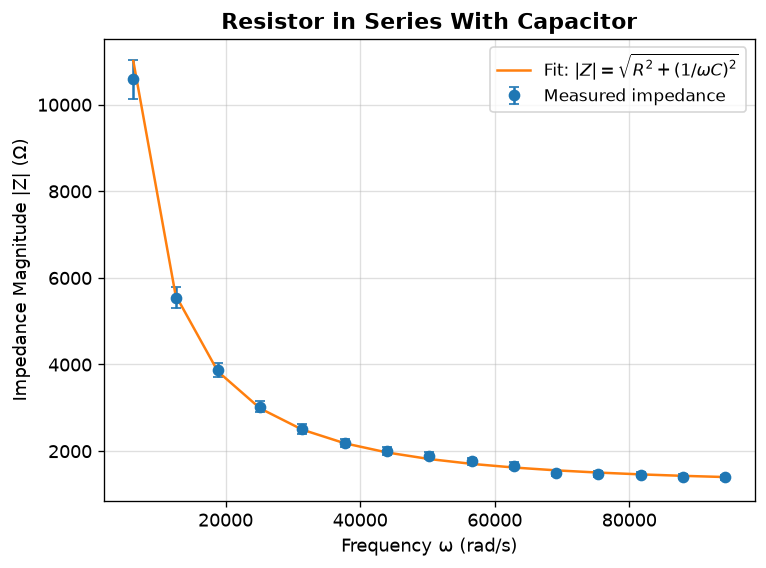

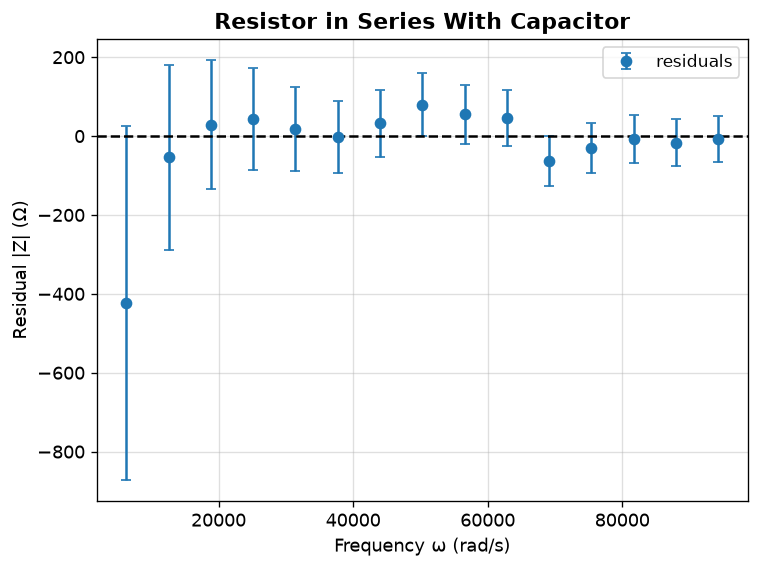

Reduced χ² = 4.59
p-value = 0.98


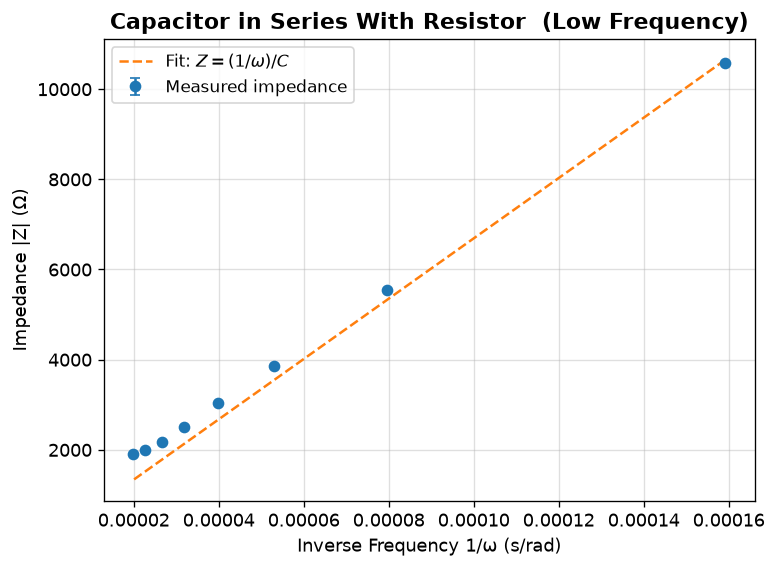

R = 1442.44 +-54.76


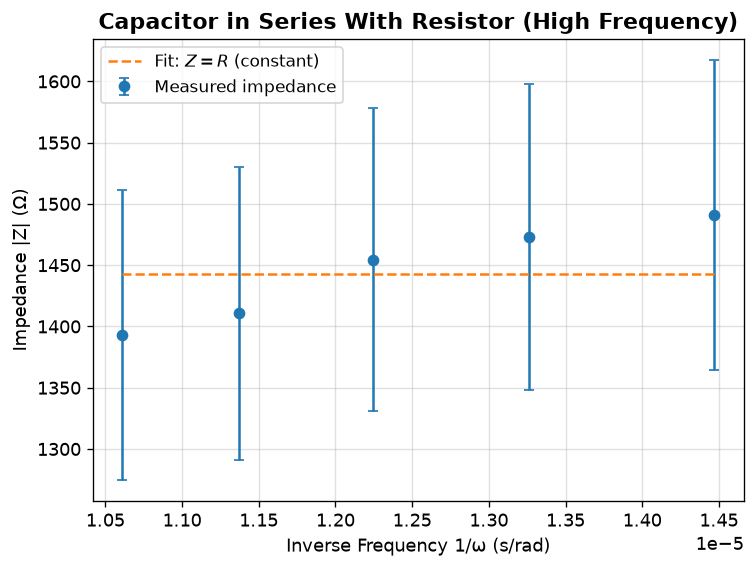

Total Resistance: 0.440 kΩ
Capacitance: 42.80 nF


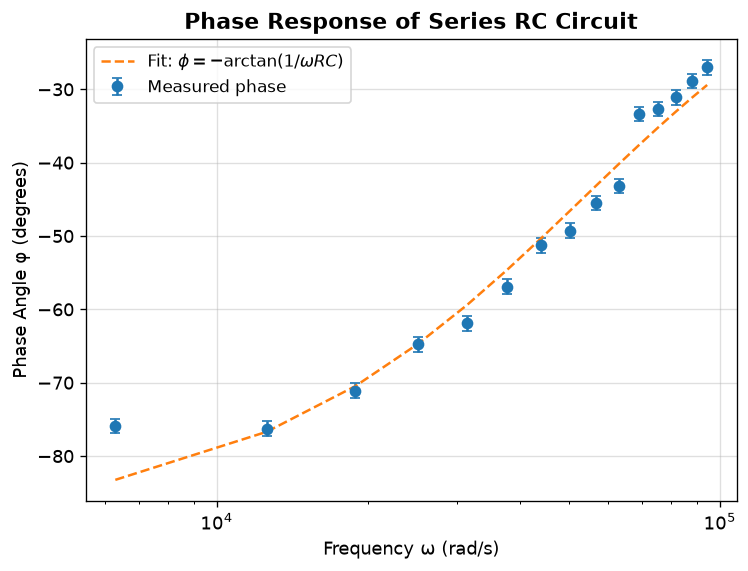

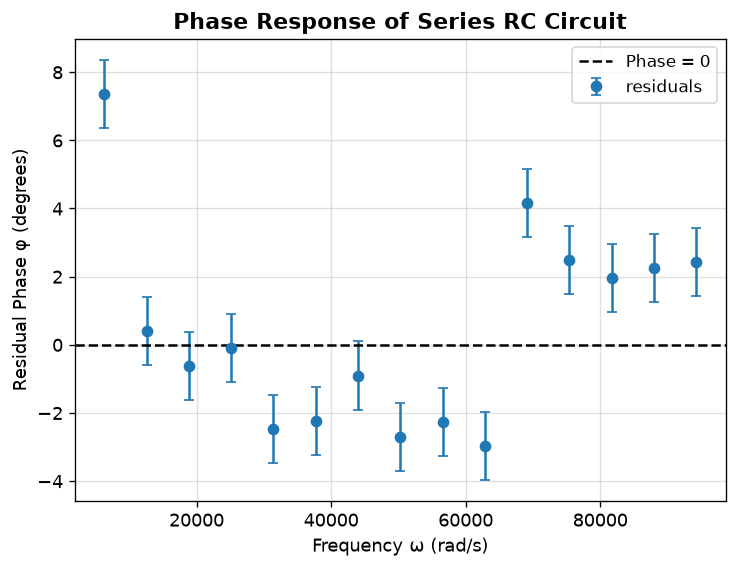

Reduced χ² (phase) = 126.23
p-value = 0.00


In [ ]:
#Capacitor and Resistor In Series 
import pandas as pd
import numpy as np

df = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Impedance_Lab_Data/phys133_ac_circuit - capcitor_and_resistor_in_series.csv')
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df = df.astype(float)

f = df.iloc[::,0] *np.pi *2 
phase = df.iloc[::,3]

R_sense = 1000

z = (df.iloc[::,1]/ df.iloc[::,2]) * R_sense

sigma_z = abs(z) * np.sqrt( (0.03)**2 + (0.03)**2 + (0.0003)**2 )




def func(f,R,C):
    return  np.sqrt((R)**2 + ((1/(f*C))**2))

popt, pcov = curve_fit(func,f,z,sigma = sigma_z, absolute_sigma = True,p0=[195,14.78e-8])

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(f,*popt)

R = popt[0]
C = popt[1]
    
print(f"R = {R:.2f} ± {perr[0]:.2f} Ω")
print(f"C = {C*1e9:.2f} ± {perr[1]*1e9:.2f} nF")

plt.errorbar (f, z,fmt = 'o',yerr = sigma_z,capsize = 3,label = 'Measured impedance')
plt.plot(f,y_fit,label = r"Fit: $|Z|=\sqrt{R^2+(1/\omega C)^2}$")
plt.legend()
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Impedance Magnitude |Z| (Ω)")
plt.title("Resistor in Series With Capacitor")
plt.grid()
plt.show()


resid = z - y_fit

plt.errorbar(f,resid,yerr = sigma_z,capsize = 3, fmt = 'o',label = 'residuals')
plt.axhline(y = 0, color = 'black', linestyle = '--')
plt.grid()
plt.legend()
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Residual |Z| (Ω)")
plt.title("Resistor in Series With Capacitor")
plt.show()

chi2 = np.sum((resid/sigma_z)**2)
dof = len(z) - len(popt)


print(f"χ² = {reduced_chi2:.2f}")
p_val = stats.chi2.sf(chi2,dof)

print(f"p-value = {p_val:.2f}")










#Low Frequency___________________________________________________

C = None

lowf = list(1/f)[:8]
z_sqr = list(z)[:8]

lowf = np.array(lowf)
z_sqr = np.array(z_sqr)

sigma_zsqr = 1/sigma_z[:8]

sigma_zsqr = np.array(list(sigma_zsqr)[:8])

def func(lowf,C):
    return lowf/(C)

popt, pcov = curve_fit(func,lowf,z_sqr,sigma = sigma_zsqr, absolute_sigma = True)

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(lowf,*popt)

plt.errorbar(lowf,z_sqr,yerr = sigma_zsqr,capsize = 3,fmt = 'o',label  = 'Measured impedance')
plt.plot(lowf,y_fit,linestyle = '--',label = r"Fit: $Z=(1/\omega)/C$")
plt.grid()
plt.legend()
plt.xlabel("Inverse Frequency 1/ω (s/rad)")
plt.ylabel("Impedance |Z| (Ω)")
plt.title("Capacitor in Series With Resistor  (Low Frequency)")
plt.show()












#High Frequency___________________________________________

C = None
lowf = None 
z_sqr = None 
sigma_zsqr = None
R = None

highf = list(1/f)[10:15]
z_sqr = list(z)[10:15]

highf = np.array(highf)
z_sqr = np.array(z_sqr)

sigma_zsqr = sigma_z[10:15]*2

sigma_zsqr = np.array(list(sigma_zsqr))

def func(highf,R):
    return np.full_like(highf,R,dtype = float)

popt, pcov = curve_fit(func,highf,z_sqr,sigma = sigma_zsqr, absolute_sigma = True)

perr = np.sqrt(np.diag(pcov))
    
print(f"R = {popt[0]:.2f} +-{perr[0]:.2f}")

y_fit = func(highf,*popt)

plt.errorbar(highf,z_sqr,yerr = sigma_zsqr,capsize = 3,fmt = 'o',label = 'Measured impedance')
plt.plot(highf,y_fit,linestyle = '--',label = r"Fit: $Z=R$ (constant)")
plt.grid()
plt.legend()
plt.xlabel("Inverse Frequency 1/ω (s/rad)")
plt.ylabel("Impedance |Z| (Ω)")
plt.title("Capacitor in Series With Resistor (High Frequency)")
plt.show()














#Phase___________________________________________________________





phase  = df.iloc[:,3]

sigma_phase = np.ones_like(phase) * 1 # degrees

C = None
R = None
R_int = None

def func(f,R,C):
    return -np.degrees(np.arctan(1/(f*(R)*C)))


popt, pcov = curve_fit(func,f,phase,sigma = sigma_phase, absolute_sigma = True,p0=[1000,1e-7],
    bounds=(0,np.inf))

perr = np.sqrt(np.diag(pcov))
    
y_fit = func(f,*popt)

R = popt[0]
C = popt[1]

print(f"Total Resistance: {R/1000:.3f} kΩ")
print(f"Capacitance: {C*1e9:.2f} nF")


plt.errorbar(f, phase, yerr=sigma_phase,capsize = 3, fmt='o',label = 'Measured phase')
plt.plot(f,y_fit,label = r"Fit: $\phi=-\arctan(1/\omega R C)$",linestyle = '--')
plt.legend()
plt.grid()
plt.xscale('log')
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Phase Angle φ (degrees)")
plt.title("Phase Response of Series RC Circuit")
plt.show()


resid = phase - y_fit

plt.errorbar(f,resid,yerr = sigma_phase,capsize = 3, fmt = 'o',label = 'residuals')
plt.axhline(y = 0, color = 'black', linestyle = '--' , label = 'Phase = 0')
plt.grid()
plt.legend()
plt.xlabel("Frequency ω (rad/s)")
plt.ylabel("Residual Phase φ (degrees)")
plt.title("Phase Response of Series RC Circuit")
plt.show()

chi2 = np.sum((resid/sigma_phase)**2)
dof = len(phase) - len(popt)
chi2 = chi2

print(f" χ² (phase) = {reduced_chi2:.2f}")

p_val = stats.chi2.sf(chi2,dof)

print(f"p-value = {p_val:.2f}")